In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys

import jax
import jax.numpy as jnp

import numpy as np
import healpy as hp
import pickle
from tqdm import tqdm

os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=1"
print(jax.devices())

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

[gpu(id=0)]


In [3]:
sys.path.append("..")
from models.np_model import NPModel
from simulations.wrapper import simulator_for_model
from models.scd import dnds
from models.psf import KingPSF

## 1. Get reasonable data values

In [5]:
s = pickle.load(open('../data/posteriors/np_sviiaf_par8_samples.p', 'rb'))

In [6]:
for k in s:
    # if k.startswith('Alm') or k.startswith('n') or k.startswith('sb'):
    #     continue
    kshow = k.ljust(15)[:14]
    print(f'{kshow} : {np.median(s[k]):.3f}, {np.quantile(s[k], 0.18):.3f} - {np.quantile(s[k], 0.82):.3f}')

Alm_0          : -0.031, -0.042 - -0.012
Alm_1          : -0.002, -0.034 - 0.031
Alm_2          : -0.018, -0.033 - 0.002
Alm_3          : -0.006, -0.035 - 0.027
Alm_4          : -0.008, -0.023 - 0.009
Alm_5          : -0.003, -0.035 - 0.031
C              : 2.538, 2.015 - 3.195
S_bub          : 1.315, 1.232 - 1.396
S_dif          : 11.147, 10.992 - 11.279
S_gce          : 0.386, 0.288 - 0.516
S_ics          : 5.925, 5.775 - 6.086
S_iso          : 0.536, 0.423 - 0.680
S_psc          : 2.869, 1.558 - 3.996
Sps_dsk        : 1.015, 0.936 - 1.096
Sps_gce        : 1.086, 0.977 - 1.180
f_bulge_poiss  : 0.253, 0.173 - 0.357
f_bulge_ps     : 0.294, 0.216 - 0.387
gamma_poiss    : 0.924, 0.756 - 1.111
gamma_ps       : 1.211, 1.115 - 1.304
lambdas_dsk    : 0.414, 0.281 - 0.567
lambdas_gce    : 0.376, 0.254 - 0.518
n1_dsk         : 5.073, 4.537 - 5.585
n1_gce         : 5.524, 4.990 - 5.822
n2_dsk         : 1.358, 0.870 - 1.770
n2_gce         : 1.551, 1.191 - 1.800
n3_dsk         : -5.456, -5.776 - 

## 2. Poissonian realization

In [ ]:
save_dir = "../outputs/poiss_sim/np_p_230827"

npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [7]:
from simulations.simulate_poiss import simulate_mu

In [8]:
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    S_dsk = 0.0, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 1.2, f_bulge_poiss = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
)
mu = simulate_mu(npmodel, var_dict)
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))
np.save(f"{save_dir}/mu.npy", mu)

In [9]:
rng_key = jax.random.PRNGKey(42)

for i in tqdm(range(100)):
    rng_key, key = jax.random.split(rng_key)
    counts = jax.random.poisson(key, mu)
    np.save(f"{save_dir}/counts_{i}.npy", np.array(counts, dtype=np.int32))

100%|██████████| 100/100 [00:03<00:00, 32.31it/s]


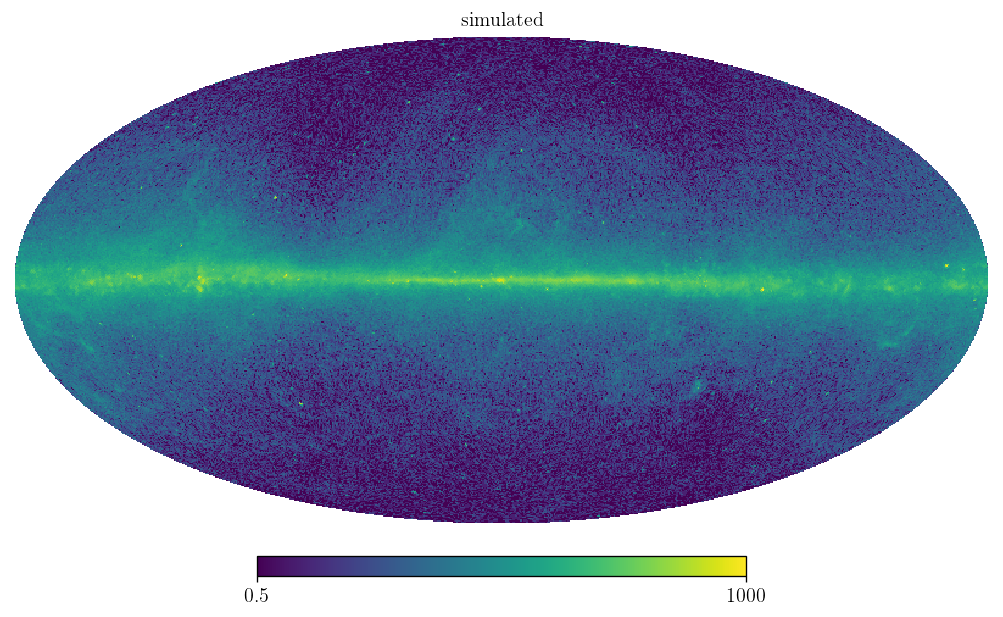

In [10]:
hp.mollview(jnp.clip(counts, 0.5, None), norm='log', max=1000, title='simulated')
plt.show()

## Non-poissonian

In [3]:
npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
)

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [4]:
save_dir = "../outputs/np_np"
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    Sps_dsk = 1.3, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 1.5, gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

In [4]:
save_dir = "../outputs/np_np_nodsk"
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0.3, S_bub = 0.2, S_psc = 0.5, S_pib = 10., S_ics = 6.,
    Sps_dsk = 0., zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 0.9, f_bulge_poiss = 0.2,
    Sps_gce = 1.5, gamma_ps = 1.2, f_bulge_ps = 0.3,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

In [4]:
save_dir = "../outputs/np_np_simple_0927"
var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0., S_bub = 0., S_psc = 0., S_pib = 10., S_ics = 6.,
    Sps_dsk = 1e-6, zs = 0.5, C = 2.5,
    S_gce = 1., gamma_poiss = 0.9, f_bulge_poiss = 0.00001,
    Sps_gce = 1.5, gamma_ps = 1.2, f_bulge_ps = 0.00001,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)
os.makedirs(save_dir, exist_ok=True)
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

## NP: Sps tempates, flat exposures

In [4]:
npmodel = NPModel(
    non_poissonian=True,
    l_max=2,
    vary_gamma=True,
    bulge_hybrid=True,
    ps_cat="3fgl",
    nside=128,
    use_flat_exposure=True,
)

Number of pixels in ROI: 6839
Loading the psf correction from: /n/home07/yitians/fermi/fermi-prob-prog/validating/psf_dir/Fermi_PSF_2GeV2_nside128.npy
Max photon count is 103


In [21]:
base_var_dict = dict(
    theta_pib = np.array([1., 0., 0.]), # O A F
    theta_ics = np.array([1., 0., 0.]),
    S_iso = 0., S_bub = 0., S_psc = 0., S_pib = 0., S_ics = 0.,
    S_gce = 0., gamma_poiss = 0.9, f_bulge_poiss = 0.00001,
    theta_bulge_poiss = np.array([1., 0., 0., 0., 0.]),
    theta_bulge_ps = np.array([0., 1., 0., 0., 0.]),
    Sps_gce = None, gamma_ps = 1.2, f_bulge_ps = 0.00001,
    Sps_dsk = None, zs = 0.5, C = 2.5,
    Sps_iso = None,
    n1_dsk = 5.0, n2_dsk = 1.3, n3_dsk = -5.4, sb1_dsk = 11., lambdas_dsk = 0.4,
    n1_gce = 5.5, n2_gce = 1.5, n3_gce = -5.5, sb1_gce = 7.6, lambdas_gce = 0.3,
    n1_iso = 5.5, n2_iso = 1.5, n3_iso = -5.5, sb1_iso = 7.6, lambdas_iso = 0.3, # identical to gce
    Alm_0 = 0., Alm_1 = 0., Alm_2 = 0., Alm_3 = 0., Alm_4 = 0., Alm_5 = 0.,
)

In [24]:
save_dir = "../outputs/ll_issue/Sps_dsk_nopscmask_deltapsf"
os.makedirs(save_dir, exist_ok=True)
var_dict = base_var_dict.copy()
var_dict['Sps_dsk'] = 1.
var_dict['Sps_gce'] = 0.
var_dict['Sps_iso'] = 0.
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

In [30]:
save_dir = "../outputs/ll_issue/Sps_gce_nopscmask_deltapsf"
os.makedirs(save_dir, exist_ok=True)
var_dict = base_var_dict.copy()
var_dict['Sps_dsk'] = 0.
var_dict['Sps_gce'] = 1.
var_dict['Sps_iso'] = 0.
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

In [41]:
save_dir = "../outputs/ll_issue/Sps_dsk_gce_nopscmask_deltapsf_unnormgen"
os.makedirs(save_dir, exist_ok=True)
var_dict = base_var_dict.copy()
var_dict['Sps_dsk'] = 1.
var_dict['Sps_gce'] = 2.
var_dict['Sps_iso'] = 0.
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

In [26]:
save_dir = "../outputs/ll_issue/Sps_dsk_iso_nopscmask_deltapsf"
os.makedirs(save_dir, exist_ok=True)
var_dict = base_var_dict.copy()
var_dict['Sps_dsk'] = 1.
var_dict['Sps_gce'] = 0.
var_dict['Sps_iso'] = 2. # iso has same config as gce
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

In [34]:
save_dir = "../outputs/ll_issue/Sps_gce_iso_nopscmask_deltapsf"
os.makedirs(save_dir, exist_ok=True)
var_dict = base_var_dict.copy()
var_dict['Sps_dsk'] = 0.
var_dict['Sps_gce'] = 1.
var_dict['Sps_iso'] = 2. # iso has same config as gce
pickle.dump(var_dict, open(f"{save_dir}/truth.p", 'wb'))

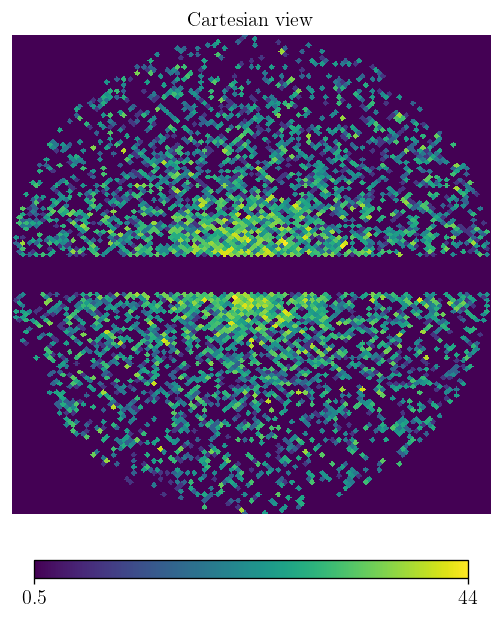

In [42]:
# preview
counts = simulator_for_model(npmodel, var_dict, no_psc_mask=True, delta_psf=True, no_plane_mask=False)
hp.cartview(np.clip(counts, 0.5, None), norm='log', latra=[-25., 25.], lonra=[-25., 25.])

In [43]:
# simulate
for i in tqdm(range(50)):
    counts = simulator_for_model(npmodel, var_dict, no_psc_mask=True, delta_psf=True, no_plane_mask=False)
    np.save(f"{save_dir}/counts_{i}.npy", np.array(counts, dtype=np.int32))

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [02:06<00:00,  2.54s/it]


## Check mean

3.016524360829715 +/- 0.007875131209747603


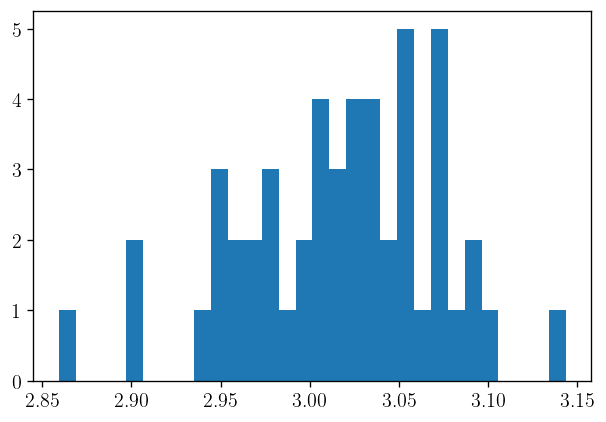

In [44]:
mean_arr = []
for i in range(50):
    counts = np.load(f"{save_dir}/counts_{i}.npy")
    mean_arr.append(np.mean(counts[~npmodel.normalization_mask]))
plt.hist(mean_arr, bins=30)
print(np.mean(mean_arr), '+/-', np.std(mean_arr) / np.sqrt(len(mean_arr)))